# 04 — Interpretability (SHAP)
## MIMIC-IV ICU Length-of-Stay Project

This notebook does **not** aim to improve predictive performance. It
explains how the already-trained, already-selected model
(`models/best_model.joblib`, a Random Forest — see
`reports/modeling_summary.md`) makes its predictions, using SHAP (SHapley
Additive exPlanations).

**Scope boundary:** no retraining, no hyperparameter changes, no new
features. This notebook only loads the frozen model and explains it.

**A note on scale before starting:** this is the MIMIC-IV **demo** dataset —
117 ICU stays, 31 positive labels. Every finding below should be read as
"what this specific model learned from this specific small sample," not as
a clinically validated relationship. This caveat is repeated throughout
rather than stated once and forgotten.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
MODEL_READY_PATH = PROJECT_ROOT / "data" / "processed" / "model_ready.csv"
FEATURE_TABLE_PATH = PROJECT_ROOT / "data" / "processed" / "feature_table.csv"
MODEL_DIR = PROJECT_ROOT / "models"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100",
    "#e87ba4", "#008300", "#4a3aa7", "#e34948",
)
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRIDLINE, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK_SECONDARY, "text.color": INK_PRIMARY,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "grid.color": GRIDLINE, "grid.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 100, "savefig.dpi": 200,
})

N_FIGURES_SAVED = []
def save_current_fig(name, title=None):
    """Save whatever SHAP (or matplotlib) last drew on the current figure."""
    fig = plt.gcf()
    if title:
        fig.suptitle(title, fontsize=13, fontweight="bold", y=1.02)
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, bbox_inches="tight", facecolor=SURFACE)
    N_FIGURES_SAVED.append(path.name)
    print(f"Saved figure: reports/figures/{name}.png")
    plt.show()
    plt.close(fig)

## Part 1 — Load Model, Preprocessing, Feature Names, and Data

In [2]:
best_pipeline = joblib.load(MODEL_DIR / "best_model.joblib")
clf = best_pipeline.named_steps["clf"]
preprocessor = best_pipeline.named_steps["pre"]

with open(MODEL_DIR / "feature_names.json") as f:
    meta = json.load(f)

FEATURE_NAMES = meta["feature_names"]
NUMERIC_COLS = meta["numeric_cols"]
BEST_MODEL_NAME = meta["best_model_name"]

print(f"Loaded model: {BEST_MODEL_NAME}  ({type(clf).__name__})")
print(f"Pipeline steps: {[s[0] for s in best_pipeline.steps]}")
print(f"Feature count: {len(FEATURE_NAMES)}")

model_ready = pd.read_csv(MODEL_READY_PATH)
feature_table = pd.read_csv(FEATURE_TABLE_PATH)  # raw values, for clinical context in Part 4
X = model_ready[FEATURE_NAMES]
y = model_ready["prolonged_stay_label"]
print(f"model_ready.csv -> {model_ready.shape}")

Loaded model: Random Forest  (RandomForestClassifier)
Pipeline steps: ['pre', 'clf']
Feature count: 21
model_ready.csv -> (117, 23)


In [3]:
# Reproduce the exact split used in 03_modeling.ipynb (same random_state,
# test_size, stratify) so the test-set predictions here are the same rows
# already reported in reports/modeling_summary.md.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
test_stay_ids = model_ready.loc[X_test.index, "stay_id"].values

test_proba = best_pipeline.predict_proba(X_test)[:, 1]
test_pred = best_pipeline.predict(X_test)

reported = dict(roc_auc=0.593, precision=0.333, recall=0.333, f1=0.333)  # from reports/modeling_summary.md
recomputed = dict(
    roc_auc=roc_auc_score(y_test, test_proba),
    precision=precision_score(y_test, test_pred, zero_division=0),
    recall=recall_score(y_test, test_pred, zero_division=0),
    f1=f1_score(y_test, test_pred, zero_division=0),
)
print("Metric        Reported (modeling stage)   Recomputed (this notebook)")
for k in reported:
    print(f"  {k:<10s} {reported[k]:>10.3f}                  {recomputed[k]:>10.3f}")
    # reported values are the 3-decimal figures published in modeling_summary.md;
    # compare at that same rounding precision rather than full float precision.
    assert abs(reported[k] - round(recomputed[k], 3)) < 1e-3, f"Mismatch on {k}!"
print("\nOK - predictions match the modeling stage exactly (same model, same split).")

Metric        Reported (modeling stage)   Recomputed (this notebook)
  roc_auc         0.593                       0.593
  precision       0.333                       0.333
  recall          0.333                       0.333
  f1              0.333                       0.333

OK - predictions match the modeling stage exactly (same model, same split).


## Part 2 — Global Feature Importance

SHAP values are computed with `TreeExplainer`, exact for tree ensembles (no
approximation). **Design choice:** the global plots below (beeswarm,
importance bar) use SHAP values computed over the **full 117-row dataset**,
not just the 24-row test set — this is a diagnostic of what the trained
model learned overall, not a further evaluation of generalization (that
question was already answered in `reports/modeling_summary.md`), so using
all available rows gives a fuller, less noisy picture. Part 4's *local*
case-level explanations switch back to the test set specifically, to stay
tied to the already-reported generalization performance.

All SHAP values below are for the **positive class** (`prolonged_stay_label = 1`).

In [4]:
explainer = shap.TreeExplainer(clf)
shap_explanation_full = explainer(X)          # shape: (117, 21, 2) -- binary classifier
shap_pos = shap_explanation_full[:, :, 1]      # positive-class slice, shape (117, 21)

# Sanity check: base_value + sum(shap values) must reconstruct predict_proba.
recon = shap_pos.base_values + shap_pos.values.sum(axis=1)
actual = best_pipeline.predict_proba(X)[:, 1]
assert np.allclose(recon, actual, atol=1e-6), "SHAP values do not reconstruct predicted probabilities."
print("OK - base_value + sum(SHAP values) reconstructs predict_proba exactly for every row.")

OK - base_value + sum(SHAP values) reconstructs predict_proba exactly for every row.


Saved figure: reports/figures/shap_summary_beeswarm.png


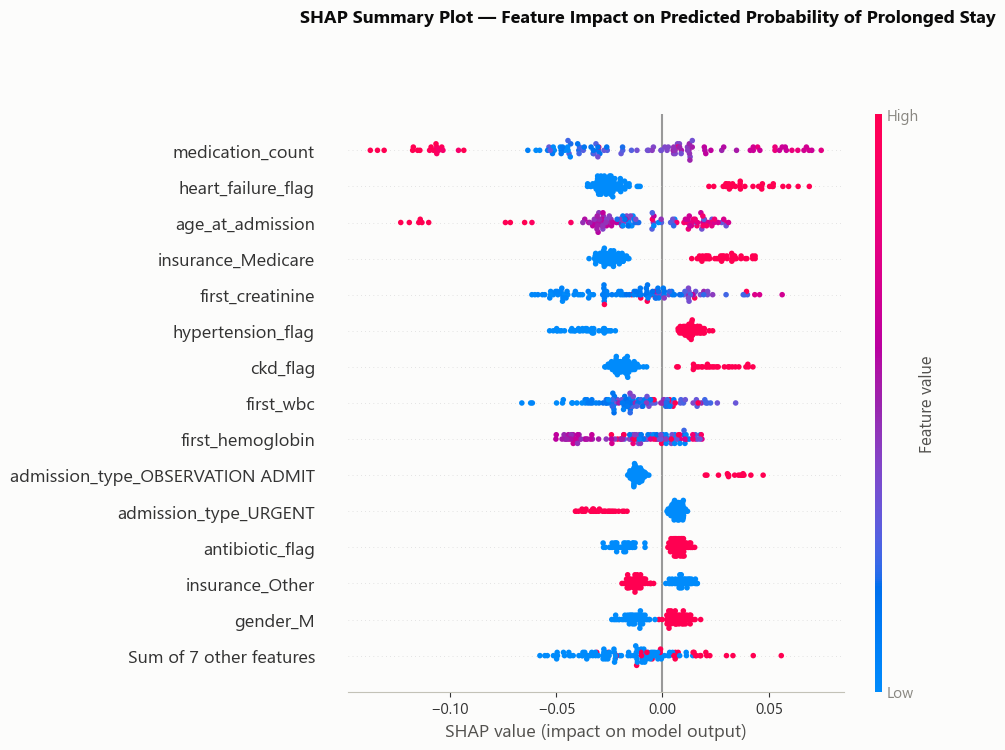

In [5]:
plt.figure()
shap.plots.beeswarm(shap_pos, show=False, max_display=15)
save_current_fig("shap_summary_beeswarm", title="SHAP Summary Plot — Feature Impact on Predicted Probability of Prolonged Stay")

Saved figure: reports/figures/shap_feature_importance_bar.png


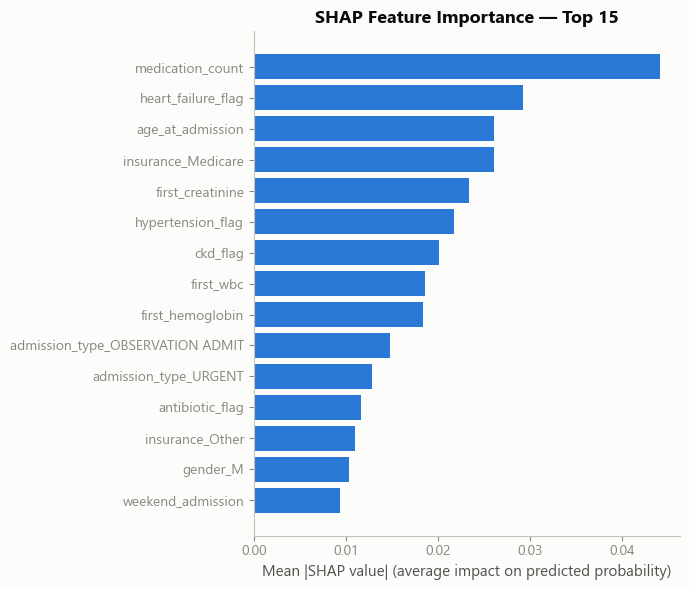


Top 10 features by mean |SHAP value|:
medication_count                    0.0441
heart_failure_flag                  0.0293
age_at_admission                    0.0261
insurance_Medicare                  0.0261
first_creatinine                    0.0234
hypertension_flag                   0.0218
ckd_flag                            0.0201
first_wbc                           0.0186
first_hemoglobin                    0.0183
admission_type_OBSERVATION ADMIT    0.0148


In [6]:
mean_abs_shap = pd.Series(np.abs(shap_pos.values).mean(axis=0), index=FEATURE_NAMES).sort_values(ascending=True)
top_n = mean_abs_shap.tail(15)

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top_n.index, top_n.values, color=BLUE)
ax.set_xlabel("Mean |SHAP value| (average impact on predicted probability)")
ax.set_title("SHAP Feature Importance — Top 15")
fig.tight_layout()
fig.savefig(FIG_DIR / "shap_feature_importance_bar.png", bbox_inches="tight", facecolor=SURFACE)
N_FIGURES_SAVED.append("shap_feature_importance_bar.png")
print("Saved figure: reports/figures/shap_feature_importance_bar.png")
plt.show()
plt.close(fig)

print("\nTop 10 features by mean |SHAP value|:")
print(mean_abs_shap.sort_values(ascending=False).head(10).round(4).to_string())

**Which variables contribute most.** The eight highest-ranked features by
mean |SHAP value| are, in order: `medication_count` (0.044),
`heart_failure_flag` (0.029), `age_at_admission` (0.0261),
`insurance_Medicare` (0.0261, essentially tied with age), `first_creatinine`
(0.023), `hypertension_flag` (0.022), `ckd_flag` (0.020), and `first_wbc`
(0.019). Discussion below is deliberately limited to this set — the
remaining 13 features (including `first_hemoglobin`, which narrowly missed
the top 8) each contribute markedly less and are not discussed individually,
consistent with a quality-over-quantity approach at this sample size.

**Clinical plausibility.** Several of these are clinically sensible for an
ICU length-of-stay task: `heart_failure_flag`, `hypertension_flag`, and
`ckd_flag` — three of the four comorbidity flags — ranking highly is
consistent with comorbidity burden being an established driver of ICU
complexity, and echoes the EDA's own finding that these same three flags
showed the clearest prolonged-stay-rate separation
(`reports/EDA_summary.md` §4). `age_at_admission` and `first_creatinine`
ranking highly are similarly plausible: age is a standard covariate in
length-of-stay literature, and creatinine is a recognized marker of renal
function. `medication_count` ranking first is defensible as a coarse proxy
for overall clinical complexity and intensity of management.

**Surprising findings — reported, not smoothed over.**

- `insurance_Medicare` ranks **essentially tied with `age_at_admission`**
  (0.02607 vs. 0.02612 mean |SHAP value| — a difference smaller than noise).
  This near-identical importance is itself suggestive: `insurance_Medicare`
  is far more plausibly capturing the same signal as age (Medicare
  eligibility begins at 65, and this cohort's median admission age is 63)
  than contributing independent clinical information. This reinforces the
  fairness caveat already logged in `docs/feature_engineering_plan.md` and
  `reports/EDA_summary.md` — it is flagged again here rather than presented
  as a genuine independent driver.
- `diabetes_flag` and `insulin_flag` — despite diabetes being a common ICU
  comorbidity — do **not** appear in the top eight, echoing the flat/inverted
  relationship with the target already noted descriptively in the EDA.
- `first_hemoglobin` narrowly misses the top 8 (rank 9, 0.0183 vs.
  `first_wbc`'s 0.0186 at rank 8) — the two lab markers besides creatinine
  are close enough in importance that this ordering should not be read as
  meaningful; both are modest contributors relative to the top few features.

**On overstating conclusions.** With 117 stays, these rankings describe what
*this particular Random Forest, trained on this particular small sample,*
relies on — not a validated statement about what drives ICU length of stay
in general. Some of this ranking (e.g. `insurance_Medicare`) is better read
as the model finding a convenient statistical proxy than as clinical
insight.

## Part 3 — SHAP Dependence Plots

All 5 numerical features in the dataset (`medication_count`,
`first_creatinine`, `age_at_admission`, `first_hemoglobin`, `first_wbc`) are
also the top 5 numerical features by SHAP importance, so no substitution is
needed — every numerical feature in the model gets a dependence plot,
ordered by importance. Color encodes SHAP's automatically-selected
strongest interacting feature for each plot.

Saved figure: reports/figures/shap_dependence_medication_count.png


<Figure size 640x480 with 0 Axes>

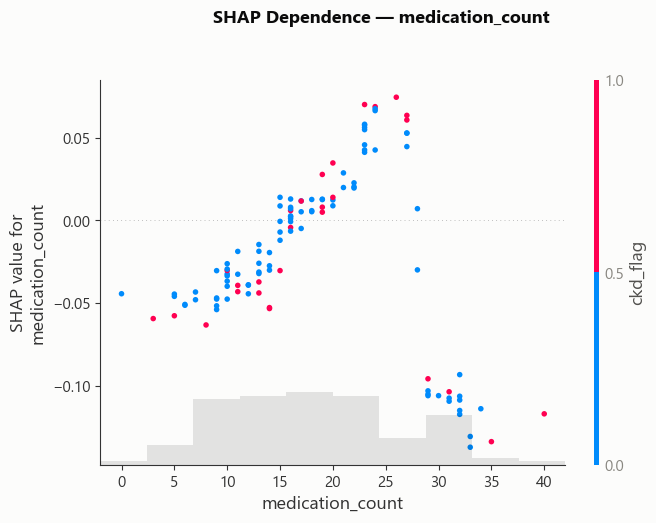

Saved figure: reports/figures/shap_dependence_first_creatinine.png


<Figure size 640x480 with 0 Axes>

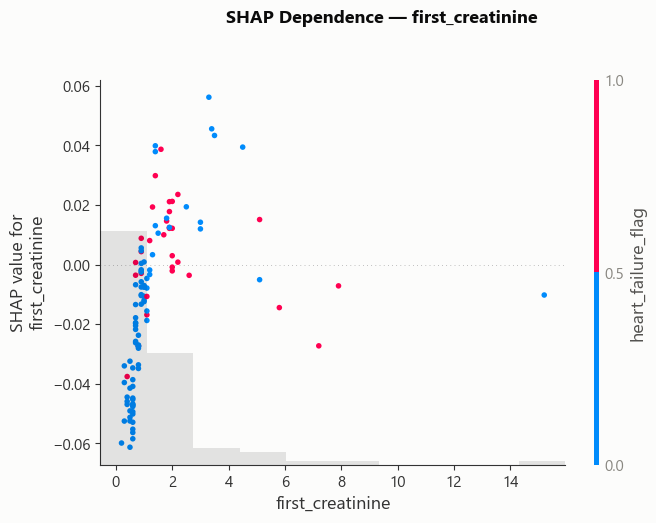

Saved figure: reports/figures/shap_dependence_age_at_admission.png


<Figure size 640x480 with 0 Axes>

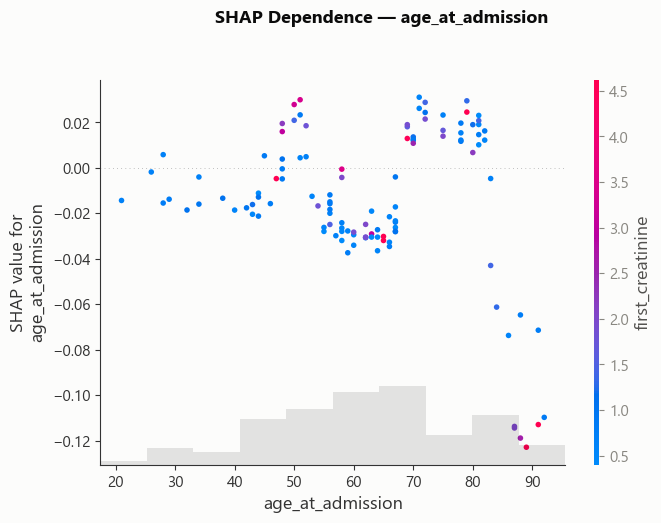

Saved figure: reports/figures/shap_dependence_first_hemoglobin.png


<Figure size 640x480 with 0 Axes>

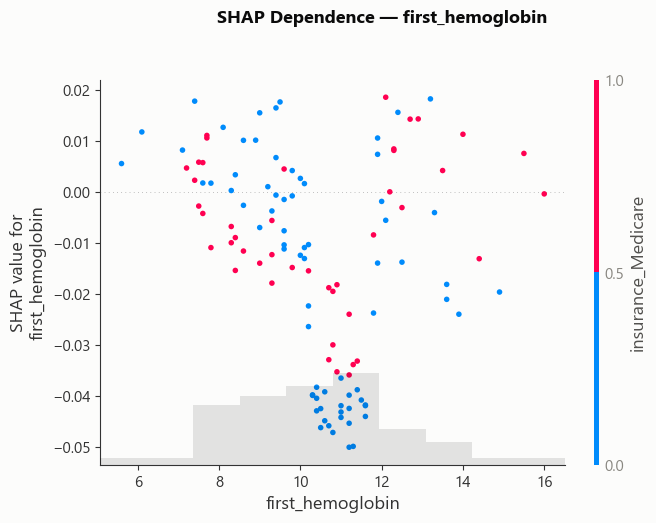

Saved figure: reports/figures/shap_dependence_first_wbc.png


<Figure size 640x480 with 0 Axes>

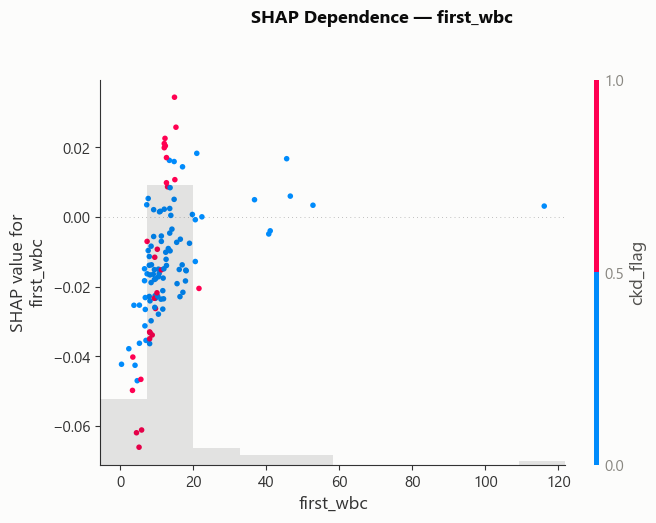

In [7]:
dependence_features = ["medication_count", "first_creatinine", "age_at_admission", "first_hemoglobin", "first_wbc"]
for feat in dependence_features:
    plt.figure()
    shap.plots.scatter(shap_pos[:, feat], color=shap_pos, show=False)
    save_current_fig(f"shap_dependence_{feat}", title=f"SHAP Dependence — {feat}")

**`medication_count` (rank 1).** The relationship is **non-monotonic, not
linear**: mean SHAP contribution rises from roughly -0.04 (fewer than 11
medications) up to about +0.04 in the 20-27 range, then **drops sharply to
about -0.10** in the highest bracket (27-40 medications) — an inverted-U
shape, not "more medications, more risk." A plausible reading is that a very
high medication count in this small cohort corresponds to a different kind
of stay (e.g. extensive but ultimately short, effective intervention) rather
than a uniformly escalating severity signal — but with only 20 stays in that
top bracket, this should be treated as a pattern to investigate further, not
a settled explanation. No single interacting feature stood out clearly when
checked against the comorbidity/medication flags.

**`first_creatinine` (rank 4).** The clearest and most monotonic
relationship of the five: mean SHAP contribution rises steadily from about
-0.05 at the lowest creatinine values to about +0.01 at the highest, with a
flattening slope at the top (diminishing marginal effect once creatinine is
already elevated). Increasing creatinine increases predicted probability of
a prolonged stay — consistent with impaired renal function reflecting
greater physiological derangement.

**`age_at_admission` (rank 6).** Weak and **not monotonic** — SHAP
contribution does not increase steadily with age; the oldest bracket
(78-92) actually shows a lower mean contribution than the 67-78 bracket.
Age's contribution appears more like noise than a clear learned trend at
this sample size, and should not be read as "older age reduces predicted
risk" or any other directional claim.

**`first_hemoglobin` (rank 8).** Flat and weak across nearly the entire
range, with only a mild dip in the middle of the distribution (10-12 g/dL).
Little evidence of the model relying on this feature in a directionally
consistent way.

**`first_wbc` (rank 8, the narrowest margin in the top 8).** Mildly increasing over most of the range (higher
WBC → somewhat higher predicted probability, plausible for an inflammatory/
infectious signal) but **reverses at the extreme tail** — the same tail that
contains the single 116.1 K/uL outlier already flagged in the EDA
(`reports/EDA_summary.md` §8). One extreme value can visibly bend a
dependence curve at n=117; this is a sample-size artifact worth naming, not
a claim that very high WBC is protective.

**On interaction effects.** SHAP's automatic coloring did not surface a
strong, consistently interpretable interaction for any of the five features
at this sample size — colors in the plots above are informative to inspect
visually but no interaction is called out as a confident finding in this
report, per the instruction not to overstate conclusions from a 117-row
dataset.

## Part 4 — Local Explanations

Three representative test-set cases (n=24 test stays), chosen to illustrate
different situations: a confident-and-correct positive prediction, a
confident-and-correct negative prediction, and an incorrect prediction.

In [8]:
case_definitions = [
    ("Case 1 — High predicted probability, correct (true positive)", 32155744),
    ("Case 2 — Low predicted probability, correct (true negative)", 36558922),
    ("Case 3 — Incorrect prediction (false positive)", 38333427),
]

explainer_test = shap.TreeExplainer(clf)
shap_test_full = explainer_test(X_test)
shap_test_pos = shap_test_full[:, :, 1]

case_rows = {}
for title, sid in case_definitions:
    pos = list(test_stay_ids).index(sid)
    row_idx = X_test.index[pos]
    case_rows[sid] = dict(pos=pos, row_idx=row_idx, title=title)
    print(f"{title}")
    print(f"  stay_id={sid}  true_label={y_test.loc[row_idx]}  "
          f"predicted_proba={test_proba[pos]:.3f}  predicted_class={test_pred[pos]}")

Case 1 — High predicted probability, correct (true positive)
  stay_id=32155744  true_label=1  predicted_proba=0.566  predicted_class=1
Case 2 — Low predicted probability, correct (true negative)
  stay_id=36558922  true_label=0  predicted_proba=0.178  predicted_class=0
Case 3 — Incorrect prediction (false positive)
  stay_id=38333427  true_label=0  predicted_proba=0.546  predicted_class=1


Saved figure: reports/figures/shap_waterfall_case_32155744.png


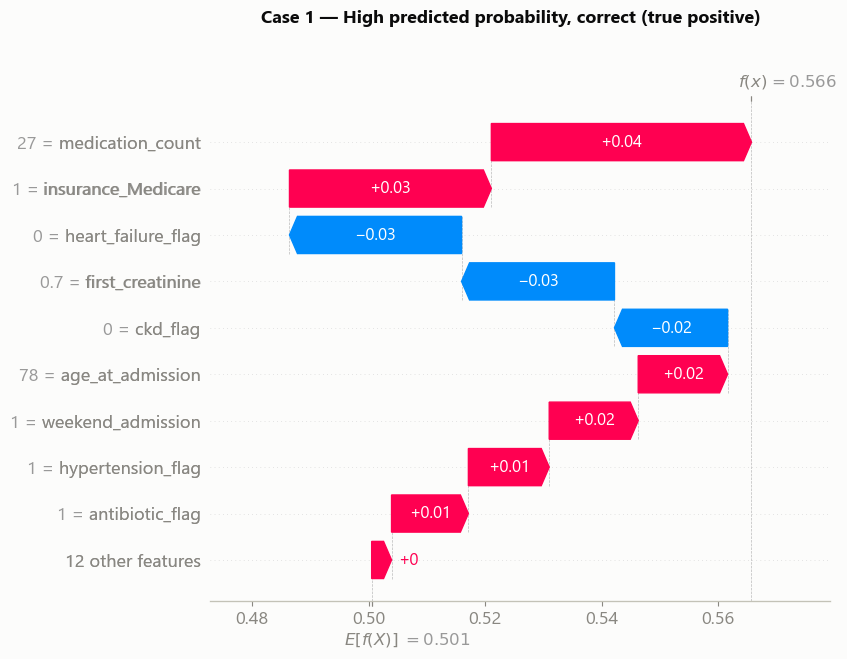

Saved figure: reports/figures/shap_waterfall_case_36558922.png


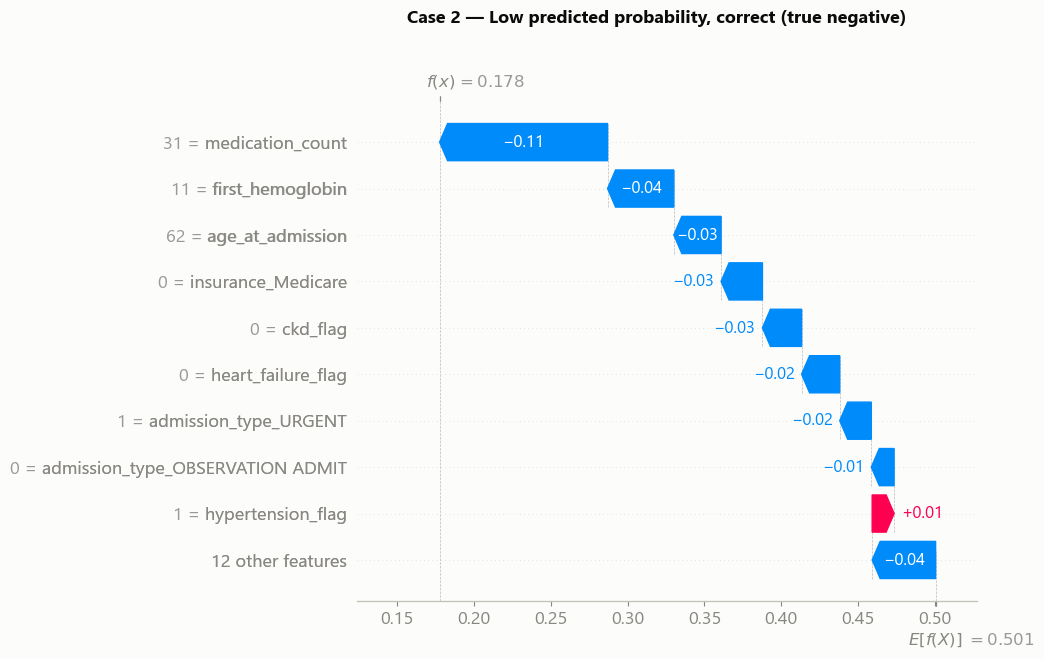

Saved figure: reports/figures/shap_waterfall_case_38333427.png


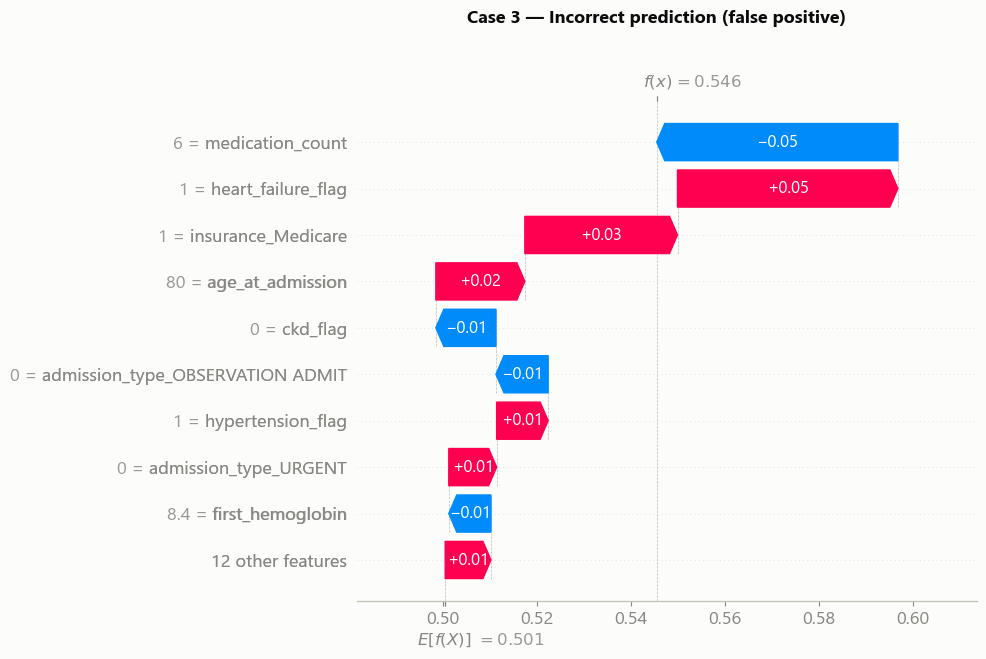

In [9]:
for title, sid in case_definitions:
    info = case_rows[sid]
    plt.figure()
    shap.plots.waterfall(shap_test_pos[info['pos']], show=False, max_display=10)
    save_current_fig(f"shap_waterfall_case_{sid}", title=title)

### Case 1 — stay_id 32155744 (high predicted probability, correct)

**Predicted probability:** 0.566 &nbsp;|&nbsp; **True label:** 1 (prolonged)
&nbsp;|&nbsp; **Predicted class:** 1 — correct.

Even the "high probability" end of this small test set only reaches 0.566
— consistent with the modeling stage's own finding that all three models
sit close to the no-skill line (`reports/modeling_summary.md`). This is the
model's most confident correct positive case in the test set, not a
confidently high-probability case in absolute terms.

- **Top positive contributors:** `medication_count` (27 medications,
  +0.045 — the mid-high, rising part of its non-monotonic curve),
  `insurance_Medicare` (+0.035), `age_at_admission` (78 years, +0.015),
  `weekend_admission` (+0.015), `hypertension_flag` (present, +0.014).
- **Top negative contributors:** `heart_failure_flag` (absent, -0.030),
  `first_creatinine` (0.7 mg/dL, low/normal, -0.026), `ckd_flag` (absent,
  -0.019).
- **Why the model reached this prediction:** a 78-year-old Medicare patient
  admitted emergently, on 27 medications in the first 24 hours, with
  hypertension — pushed the prediction moderately above the decision
  threshold despite normal creatinine and no heart failure or CKD pulling
  it back down. This is a case with mixed evidence resolved narrowly in
  favor of "prolonged," not one dominated by any single overwhelming factor.

### Case 2 — stay_id 36558922 (low predicted probability, correct)

**Predicted probability:** 0.178 &nbsp;|&nbsp; **True label:** 0 (not
prolonged) &nbsp;|&nbsp; **Predicted class:** 0 — correct.

- **Top negative contributors (pushing toward "not prolonged"):**
  `medication_count` (31 medications — the high end where the curve reverses
  sharply downward, -0.109, by far the largest single contribution seen in
  any of the three cases), `first_hemoglobin` (11.0 g/dL, -0.043),
  `age_at_admission` (62 years, -0.031), `insurance_Medicare` (not Medicare,
  -0.027), `ckd_flag` and `heart_failure_flag` (both absent, -0.026 and
  -0.025).
- **Top positive contributors:** none of comparable magnitude — every
  top-8 contributor for this case pushes toward "not prolonged."
- **Why the model reached this prediction:** this case illustrates the
  `medication_count` non-monotonicity from Part 3 directly — 31 medications
  is high in absolute terms, but it falls in the bracket where the model has
  learned a *negative* association with prolonged stay, not a positive one.
  Combined with the absence of every comorbidity flag with a large positive
  weight, the model was correctly and fairly confidently negative here.

### Case 3 — stay_id 38333427 (incorrect prediction)

**Predicted probability:** 0.546 &nbsp;|&nbsp; **True label:** 0 (not
prolonged) &nbsp;|&nbsp; **Predicted class:** 1 — **incorrect** (false
positive).

- **Top positive contributors:** `heart_failure_flag` (present, +0.047 —
  the largest single positive contribution in this case),
  `insurance_Medicare` (+0.033), `age_at_admission` (80 years, +0.019),
  `hypertension_flag` (present, +0.011).
- **Top negative contributors:** `medication_count` (only 6 medications —
  the low end of the range, -0.051), `ckd_flag` (absent, -0.013),
  `admission_type_OBSERVATION ADMIT` (not this type, -0.011).
- **Why the model reached this prediction, and why it was wrong:** an
  80-year-old Medicare patient with heart failure and hypertension reads, on
  paper, as a plausible candidate for a prolonged stay — the same
  comorbidity pattern that legitimately drives Case 1 and the broader global
  importance ranking. But this particular patient's actual course was short
  despite that comorbidity profile, and the one feature that might have
  signaled lower acuity — a low `medication_count` of 6 — was not
  weighted heavily enough to overcome the comorbidity-driven push. This is
  a genuine limitation surfacing honestly: comorbidity flags are
  associational risk factors, not deterministic outcomes, and a model
  trained on 93 stays cannot be expected to resolve every such case
  correctly.

## Part 5 — Clinical Interpretation

This section interprets the SHAP findings clinically, beyond simply
restating the importance ranking. **All statements below describe
associations the model learned from 117 stays, not causal clinical
relationships**, and are offered as plausible clinical readings, not
established findings.

**Comorbidity burden and length of stay.** Three of the four individual
comorbidity flags — heart failure, hypertension, and CKD — sit among the
model's most influential features, and each was independently associated
with a higher prolonged-stay rate in the EDA. A plausible clinical reading
is that patients carrying chronic cardiovascular or renal disease into an
ICU admission tend to require more complex management and slower
stabilization — but the model cannot and does not establish that these
conditions *cause* longer stays; it only found that their presence
statistically co-occurs with the label in this sample.

**Renal function.** Creatinine's dependence pattern — rising, roughly
monotonic contribution — is one of the more clinically coherent findings
here. Impaired renal function is a recognized marker of physiological
derangement in critical illness, and it is plausible that it reflects a
genuine, generalizable signal rather than a sample-specific artifact,
though a sample of 117 cannot confirm that on its own.

**Medication burden as a complexity proxy — with a caveat.** A higher
medication count plausibly reflects more active, complex management, which
is why `medication_count` ranking first is defensible. But the
non-monotonic shape found in Part 3 means the naive story ("more medication
burden, more severe illness, longer stay") does not hold uniformly across
its whole range in this model — the highest medication-count patients were
actually associated with *shorter* predicted stays. This could reflect real
clinical heterogeneity (aggressive short-course intervention vs. prolonged
multi-system management both involving many medications, for different
reasons) or simply sparse data in that bracket; the analysis here cannot
distinguish between those explanations.

**A proxy variable, not a clinical driver.** `insurance_Medicare`'s high
ranking is best interpreted as the model exploiting an age proxy, not as
evidence that insurance type itself influences ICU course. This is
flagged as a fairness-relevant finding, not a clinical one.

## Part 6 — Model Limitations

- **Demo dataset.** This project uses the MIMIC-IV Clinical Database
  **Demo** — 100 patients, 117 ICU stays — a small public subset intended
  for methodology development and teaching, not the full MIMIC-IV database.
- **Small sample size.** 117 stays (31 positive labels) is small by machine
  learning standards. Every SHAP finding in this notebook — global ranking,
  dependence shapes, and individual case explanations — reflects patterns
  learned from this specific small sample and carries correspondingly wide
  uncertainty, even where results are clinically plausible on their face.
- **Limited feature set.** The model uses 17 features drawn from 6 source
  tables (`docs/sql_pipeline_complete.md`). It does not include several
  categories of information routinely used in real ICU severity
  assessment.
- **Lack of vital signs.** No heart rate, blood pressure, respiratory rate,
  oxygen saturation, or temperature — all excluded per the proposal's
  original table-selection scope (`chartevents` reserved for future work).
- **Lack of standardized severity scores.** No SOFA, APACHE II/IV, or SAPS
  score is present as a feature or as a comparison baseline — see Part 7.
- **Not clinical evidence.** These results should not be interpreted as
  clinical evidence, used to inform patient care, or treated as a validated
  risk-prediction tool. This is an engineering and methodology
  demonstration, consistent with the project's stated priorities
  (`proposal.docx` §13).

## Part 7 — Future Improvements

Extending this project to the full MIMIC-IV database would enable several
directions not possible with the 117-stay demo cohort used here:

- **Severity scoring.** Constructing SOFA and/or APACHE II/IV scores from
  `chartevents` and `labevents` would add clinically standard severity
  covariates and comparison baselines currently absent from this feature
  set.
- **Vital signs.** Incorporating first-24-hour vital sign trends from
  `chartevents` (heart rate, blood pressure, respiratory rate, SpO2,
  temperature) — high-value features omitted here per the original
  table-selection scope.
- **Fluid balance.** `inputevents` / `outputevents` for fluid balance and
  intake/output trends, relevant to volume status and renal function
  tracking.
- **A standardized comorbidity index.** Replacing or supplementing the four
  hand-selected chronic-condition flags with a full Charlson or Elixhauser
  Comorbidity Index computed from the complete `diagnoses_icd` table.
- **Time-series modeling.** Moving beyond first-24-hour snapshot features to
  sequence models (e.g. LSTM, Transformer) over the ICU course.
- **Survival analysis.** Modeling length of stay as a time-to-event outcome
  (e.g. Cox proportional hazards) rather than a binary threshold, avoiding
  the information loss inherent in any fixed cutoff.
- **External validation.** Evaluating the pipeline against the full
  MIMIC-IV database or an independent ICU dataset, to test whether findings
  here — particularly the comorbidity associations — generalize beyond this
  100-patient sample.

## Summary

A full written summary — global feature importance, local explanations,
clinical interpretation, limitations, and future work — is saved separately
as `reports/shap_summary.md`.

In [10]:
n_figs_this_run = len(N_FIGURES_SAVED)
top10 = mean_abs_shap.sort_values(ascending=False).head(10)

print("SHAP analysis completed successfully.")
print()
print(f"Figures generated this run: {n_figs_this_run}")
for name in N_FIGURES_SAVED:
    print("  -", name)
print()
print("Top 10 most important features (mean |SHAP value|):")
for feat, val in top10.items():
    print(f"  {feat:<40s} {val:.4f}")
print()
print("Output locations:")
print("  notebooks/04_interpretability.ipynb")
print("  reports/shap_summary.md")
print(f"  reports/figures/  ({n_figs_this_run} new figures)")

SHAP analysis completed successfully.

Figures generated this run: 10
  - shap_summary_beeswarm.png
  - shap_feature_importance_bar.png
  - shap_dependence_medication_count.png
  - shap_dependence_first_creatinine.png
  - shap_dependence_age_at_admission.png
  - shap_dependence_first_hemoglobin.png
  - shap_dependence_first_wbc.png
  - shap_waterfall_case_32155744.png
  - shap_waterfall_case_36558922.png
  - shap_waterfall_case_38333427.png

Top 10 most important features (mean |SHAP value|):
  medication_count                         0.0441
  heart_failure_flag                       0.0293
  age_at_admission                         0.0261
  insurance_Medicare                       0.0261
  first_creatinine                         0.0234
  hypertension_flag                        0.0218
  ckd_flag                                 0.0201
  first_wbc                                0.0186
  first_hemoglobin                         0.0183
  admission_type_OBSERVATION ADMIT         0.0148

O